# Analyse Data

In [ ]:
"""Analyse Data Used to Fine-Tune scGPT model

Structure:
    1. Imports, Variables, Functions
    2. Load Data
    3. Exploratory Analysis
"""

# 1. Imports, Variables, Functions
# imports
import sys
import os, numpy as np
import json
import h5py, scanpy as sc
sys.path.append("../..")
from src.utils import io 
import pandas as pd
from src.utils import viz as vz
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from matplotlib import cm
import sys
from src.training import helpers as tr_h



# variables
run_dir = os.path.join("..","..","outputs","run-25-08-18-03")
data_path = "/aloy/home/ddalton/projects/scGPT_playground/data/pp_data-25-08-14-01/data.h5ad"

# functions

# 2. Load Data
# (
#     _,
#     _,
#     _,
#     _,
#     _,
#     _,
#     _,
#     _,
#     _,
#     _,
#     _,
#     _,
#     adata,
#     _,
#     _,
#     _,
# ) = io.load_run_output(run_dir)

# X = np.array(adata.X)

adata = sc.read_h5ad(data_path)
X = np.array(adata.X)

# 3. Exploratory Analysis

# how many samples
n_disease_samples = adata[adata.obs["disease"] != "Control"].shape[0]
n_control_samples = adata[adata.obs["disease"] == "Control"].shape[0]

# how many samples per library stratergy
n_rna_seq_samples = adata[adata.obs["library"] == "RNA-Seq"].shape[0]
n_ma_seq_samples = adata[adata.obs["library"] == "microarray"].shape[0]


# how many genes
n_genes = X.shape[1] - np.isnan(X).sum(axis=0)

# how many datasets
n_datasets = adata.obs['dataset'].nunique()

# how many diseases
n_diseases = adata[adata.obs["disease"] != "Control"].obs['do_id'].nunique()

# how many samples per diseasen_samples_per_disease = adata[adata.obs["disease"] != "Control"].obs['do_id'].value_counts().values

# how many samples per dataset
n_samples_per_dataset = adata.obs['dataset'].value_counts().values

df_expl = pd.DataFrame({
    "Nº Datasets": [n_datasets],
    "Nº Diseases": [n_diseases],
    "Nº Samples Disease": [n_disease_samples],
    "Nº Samples Control": [n_control_samples],
    "Nº Samples RNA-Seq": [n_rna_seq_samples],
    "Nº Samples Microarray": [n_ma_seq_samples],
    "Nº Samples per Disease": [f"{np.mean(n_samples_per_disease):.0f} ± {np.std(n_samples_per_disease):.0f}"],
    "Nº Samples per Dataset": [f"{np.mean(n_samples_per_dataset):.0f} ± {np.std(n_samples_per_dataset):.0f}"],
    "Nº Genes per Sample": [f"{np.mean(n_genes):.0f} ± {np.std(n_genes):.0f}"],

})

In [4]:
# dataframe exploration
df_expl.T

,0
Nº Datasets,660
Nº Diseases,131
Nº Samples Disease,21246
Nº Samples Control,14380
Nº Samples RNA-Seq,35626
Nº Samples Microarray,0
Nº Samples per Disease,162 ± 237
Nº Samples per Dataset,54 ± 136
Nº Genes per Sample,18252 ± 8312


In [3]:
# get top k most present genes
mask_genes = tr_h.get_top_k_most_present_genes(
        adata, k=3501
    )

# clean dataset
adata = tr_h.clean_adata_qc(adata)

# perform combat analysis
adata_combat = tr_h.apply_combat_adata(adata)


INFO:root:Nº genes: 20608, Nº samples: 35626
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
INFO:root:Top 3501 most present genes selected. - >= 35581


Nº of datasets with +2 control samples: 660
Nº of datasets with +2 disease samples: 660
Nº of datasets with +2 samples (control and disease): 660
adata shape after filtering datasets with +2 samples: (35626, 20608)
Nº of passed diseases 131/ 131


/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


Found 13 genes with zero variance.


In [4]:
import random, seaborn as sns
def plot_adata_kde(adata:sc.AnnData, title:str="", sample_size:int=100)->None:
    plt.figure(figsize=(4, 4))
    for lib in adata.obs["library"].unique():
        X = adata[adata.obs["library"] == lib].X
        print("Nº of points", X.shape)
        print("Nº of GEx points", X.flatten().shape)
    
        # sample from both distributions
        X_sample = random.sample(list(X.flatten()), sample_size)

        # plot
        sns.kdeplot(X_sample, label=lib, fill=True)

    plt.title(title)
    plt.legend()

Nº of points (21246, 20608)
Nº of GEx points (437837568,)


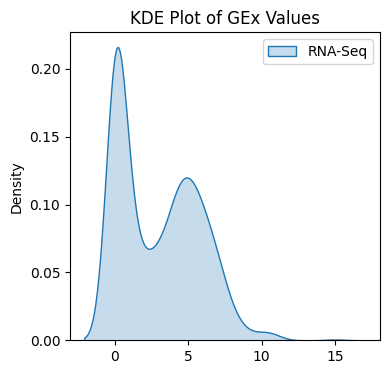

In [5]:
plot_adata_kde(adata, title="KDE Plot of GEx Values", sample_size=1000)


In [1]:
import random, seaborn as sns
def plot_adata_tsne(adata: sc.AnnData, labels: list, title:str="t-SNE", sample:int=None)->None:
    
    X = adata.X
    labels = np.array(labels)
    if isinstance(X, np.ndarray):
        X = np.array(X)
    else:
        X = X.toarray()  # in case it's sparse

    # Fill NaNs
    X = np.nan_to_num(X, nan=0.0)

    if sample:
        _idxs = random.sample(range(X.shape[0]), sample)
        X = X[_idxs]
        labels = labels[_idxs]

    # Compute t-SNE
    tsne = TSNE(n_components=2, random_state=42, init="pca", perplexity=30)
    X_tsne = tsne.fit_transform(X)

    # Build dataframe for plotting
    df = pd.DataFrame({
        "tSNE1": X_tsne[:, 0],
        "tSNE2": X_tsne[:, 1],
        "Type": labels
    })

    # --- Plot ---
    plt.figure(figsize=(6, 4))
    sns.scatterplot(
        data=df,
        x="tSNE1",
        y="tSNE2",
        hue="Type",
        palette="tab10",
        s=15,
        alpha=0.8
    )
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()



def plot_adata_kde(adata:sc.AnnData, title:str="")->None:
    X_rna_seq = adata[adata.obs["library_strategy"] == "RNA-Seq"].X
    X_ma = adata[adata.obs["library_strategy"] == "Microarray"].X
    print(X_rna_seq.shape)
    print(X_rna_seq.flatten().shape)
    # sample from both distributions
    X_rna_seq_sample = random.sample(list(X_rna_seq.flatten()), 100)
    X_ma_sample = random.sample(list(X_ma.flatten()), 100)


    # plot
    plt.figure(figsize=(4, 4))
    sns.kdeplot(X_rna_seq_sample, label="RNA-Seq", fill=True)
    sns.kdeplot(X_ma_sample, label="Microarray", fill=True)
    plt.title(title)
    plt.legend()

plot_adata_tsne(adata, labels=adata.obs["library"].tolist(), title="t-SNE Plot of Library Strategies")

plot_adata_kde(adata, title="KDE Plot of RNA-Seq and Microarray")


NameError: name 'sc' is not defined

In [1]:
import importlib
importlib.reload(vz)

NameError: name 'vz' is not defined

NameError: name 'adata' is not defined

Number of DO leaves: 9018
Generated multilabel vectors for level 1 nodes with shape (35626, 51)
Cleaned multilabel vectors for top 50 nodes with shape (35626, 48)
14380 samples	Node Control
554 samples	Node DOID:0014667 - disease of metabolism
518 samples	Node DOID:0050117 - disease by infectious agent
214 samples	Node DOID:0050155 - sensory system disease
422 samples	Node DOID:0050177 - monogenic disease
8477 samples	Node DOID:0050686 - organ system cancer
8103 samples	Node DOID:0050687 - cell type cancer
18 samples	Node DOID:0050735 - X-linked monogenic disease
201 samples	Node DOID:0050736 - autosomal dominant disease
158 samples	Node DOID:0050737 - autosomal recessive disease
359 samples	Node DOID:0050739 - autosomal genetic disease
9 samples	Node DOID:0060072 - benign neoplasm
9 samples	Node DOID:0060085 - organ system benign neoplasm
162 samples	Node DOID:0080000 - muscular disease
653 samples	Node DOID:0080001 - bone disease
27 samples	Node DOID:0080015 - physical disorder
352 s

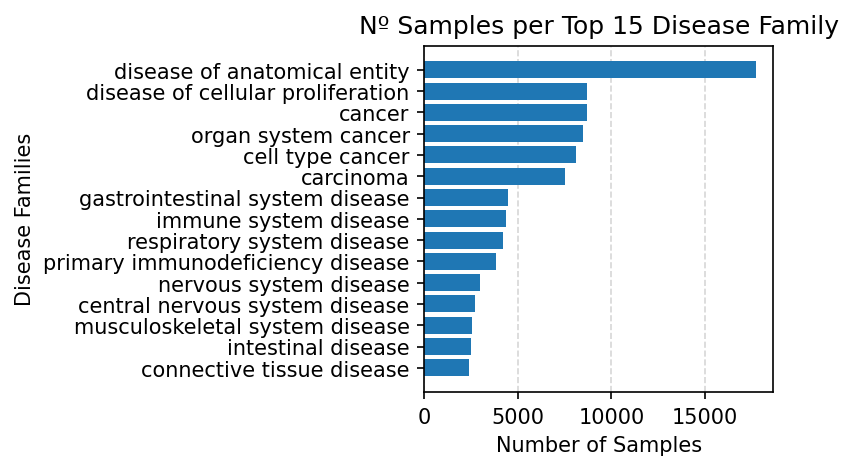

In [ ]:
# viz top families
vz.plot_adata_top_families(adata, n_class_nodes=50, top_n=15)

In [ ]:
from src.utils import utils as ut
df_info = ut.load_dsa_info()
dsaid_2_tissue = dict(zip(df_info["dsaid"], df_info["tissue"]))


adata.obs["tissue"] = adata.obs["dsaid"].map(dsaid_2_tissue)


In [ ]:
# replace nans
adata.obs["tissue"].fillna("unknown", inplace=True)

/tmp/ipykernel_919456/2865042168.py:47: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(lab):
/tmp/ipykernel_919456/2865042168.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(cats)) if len(cats) <= 20 else cm.get_cmap("gist_rainbow", len(cats))


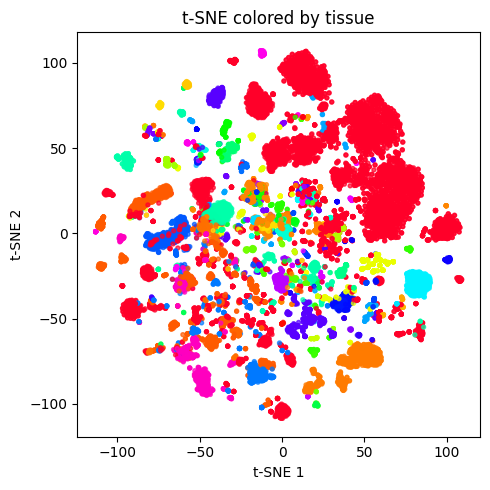

In [ ]:
plot_tsne_adata(adata, "tissue")

/tmp/ipykernel_919456/2229875925.py:21: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(lab):
/tmp/ipykernel_919456/2229875925.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(cats)) if len(cats) <= 20 else cm.get_cmap("gist_rainbow", len(cats))


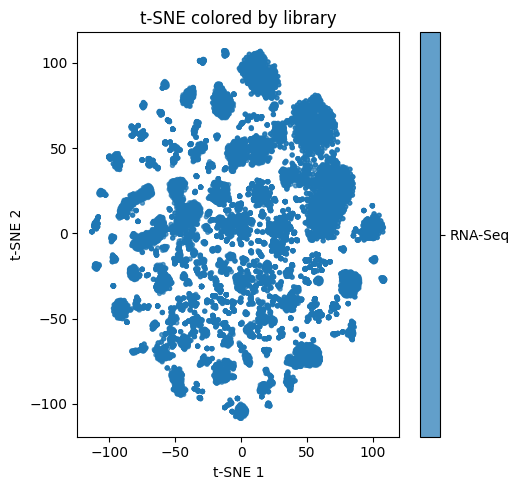

In [ ]:
plot_tsne_adata(adata, "library")

/tmp/ipykernel_919456/2229875925.py:21: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(lab):
/tmp/ipykernel_919456/2229875925.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(cats)) if len(cats) <= 20 else cm.get_cmap("gist_rainbow", len(cats))


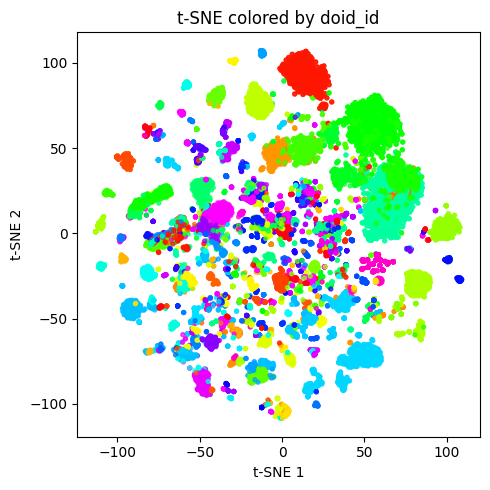

In [ ]:
plot_tsne_adata(adata, "doid_id")

In [ ]:
import importlib
importlib.reload(vz)

<module 'src.utils.viz' from '/aloy/home/ddalton/projects/scGPT_playground/notebooks/pipeline/../../src/utils/viz.py'>

In [ ]:
vz.plot_tsne_adata(adata, "dataset",sample_size=10000, dpi=150)